In [1]:
#Import the required packages
#Import package pandas for data analysis
import pandas as pd

# Import package numpy for numeric computing
import numpy as np

# Import package matplotlib for visualisation/plotting
import matplotlib.pyplot as plt

#For showing plots directly in the notebook run the command below
%matplotlib inline

# For saving multiple plots into a single pdf file
from matplotlib.backends.backend_pdf import PdfPages


In [2]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Cleaned.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region
0,Wexford,62500.0,No,No,Second-Hand Dwelling house /Apartment,2016,7,NON_DUBLIN
1,Cork,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
2,Wexford,94000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
3,Leitrim,149500.0,No,Yes,New Dwelling house /Apartment,2016,2,NON_DUBLIN
4,Mayo,170000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,NON_DUBLIN
5,Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
6,Kildare,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
7,Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,DUBLIN14
8,Waterford,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
9,Kilkenny,320000.0,No,Yes,New Dwelling house /Apartment,2016,12,NON_DUBLIN


In [3]:
# check the type of the columns
df.dtypes

County                    object
Price(€)                 float64
NotFullMarketPrice        object
VATExclusive              object
DescriptionofProperty     object
SaleYear                   int64
SaleMonth                  int64
Region                    object
dtype: object

In [4]:
# correct the feature types
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')
for col in df.select_dtypes('int64').columns:
    df[col] = df[col].astype('category')
df.dtypes

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty    category
SaleYear                 category
SaleMonth                category
Region                   category
dtype: object

In [5]:
# Descriptive stats for numeric features only.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price(€),53996.0,280407.849859,166508.296215,5250.0,158000.0,250987.5,365000.0,675500.0


In [6]:
#Look at the categorical features only
category_columns = df.select_dtypes(['category']).columns
category_columns
# Descriptive stats for categorical features only.
df[category_columns].describe().T

,count,unique,top,freq
County,53996,26,Dublin,16678
NotFullMarketPrice,53996,2,No,51170
VATExclusive,53996,2,No,44295
DescriptionofProperty,53996,3,Second-Hand Dwelling house /Apartment,44139
SaleYear,53996,9,2018,6000
SaleMonth,53996,12,12,6347
Region,53996,24,NON_DUBLIN,37318


/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/2959089736.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('County')['Price(€)'].median().sort_values()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/2959089736.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


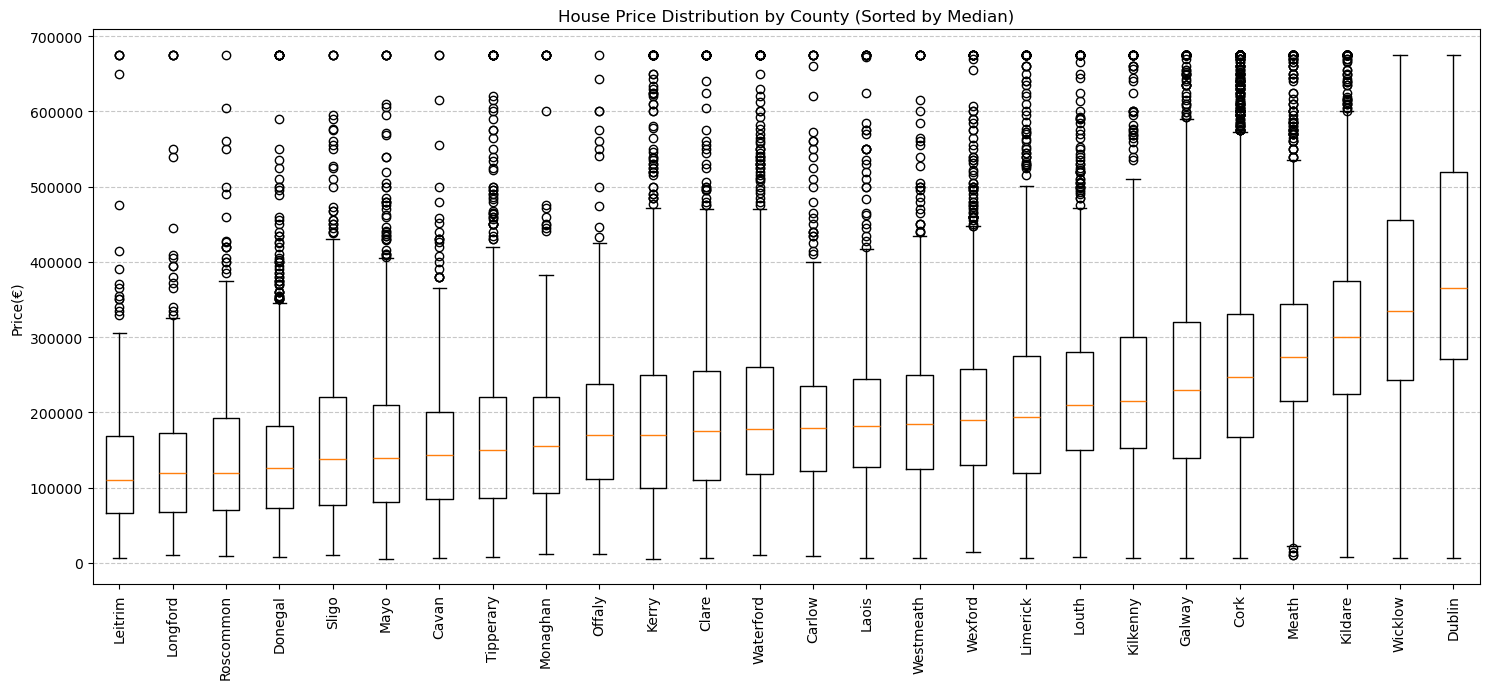

In [7]:
# pair the price with county

# sort by median
grouped = df.groupby('County')['Price(€)'].median().sort_values()

data_to_plot = [df[df['County'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by County (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/1668246194.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Region')['Price(€)'].median().sort_values()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/1668246194.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


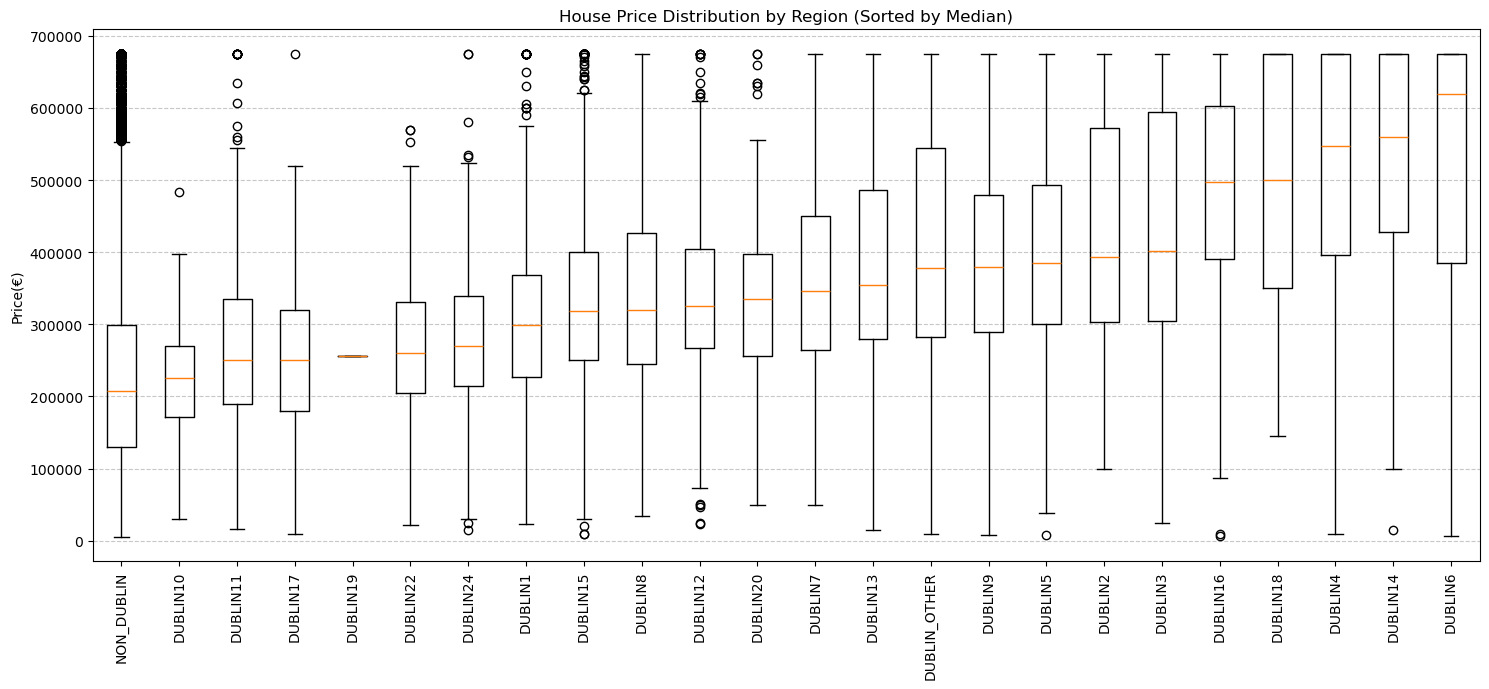

In [8]:
# pair the price with Region

# sort by median
grouped = df.groupby('Region')['Price(€)'].median().sort_values()

data_to_plot = [df[df['Region'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by Region (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/2218628964.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleYear')['Price(€)'].median()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/2218628964.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


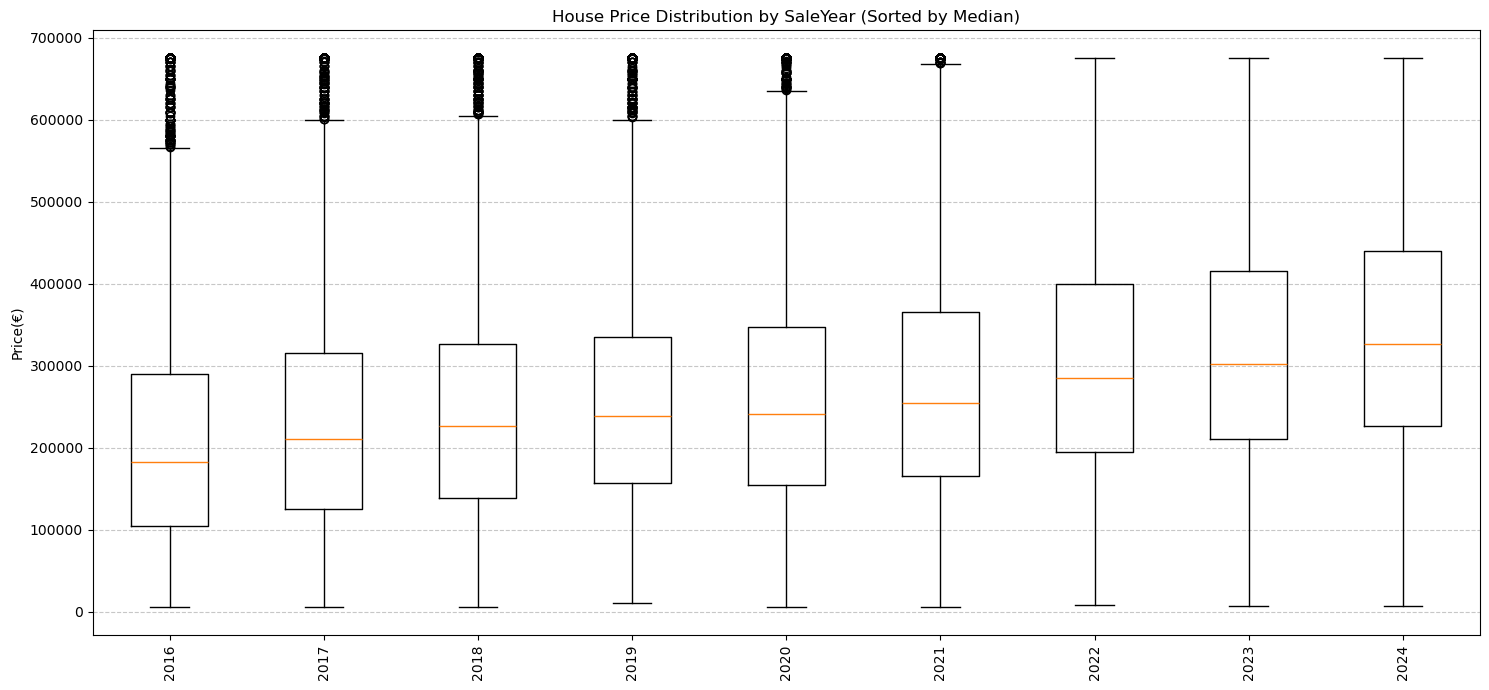

In [9]:
# pair the price with SaleYear

# sort by year
grouped = df.groupby('SaleYear')['Price(€)'].median()

data_to_plot = [df[df['SaleYear'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleYear (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/1757054261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleMonth')['Price(€)'].median()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/1757054261.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


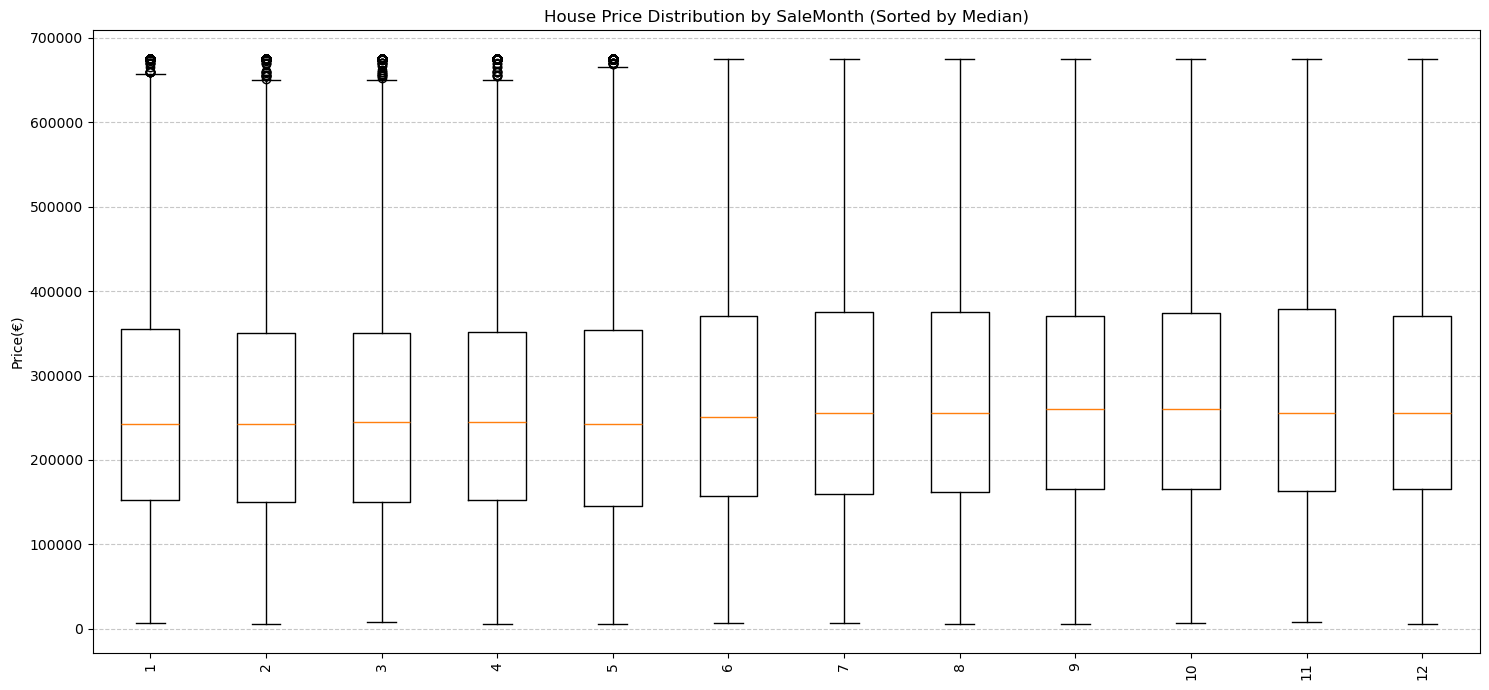

In [10]:
# pair the price with SaleMonth

# sort by month
grouped = df.groupby('SaleMonth')['Price(€)'].median()

data_to_plot = [df[df['SaleMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

In [11]:
# combine year and month together.
df['YearMonth']=df['SaleYear'].astype('int64')*100+df['SaleMonth'].astype('int64')
df['YearMonth']=df['YearMonth'].astype('category')
df['SaleYear']=df['SaleYear'].astype('category')
df['SaleMonth']=df['SaleMonth'].astype('category')

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/276334388.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('YearMonth')['Price(€)'].median()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/276334388.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


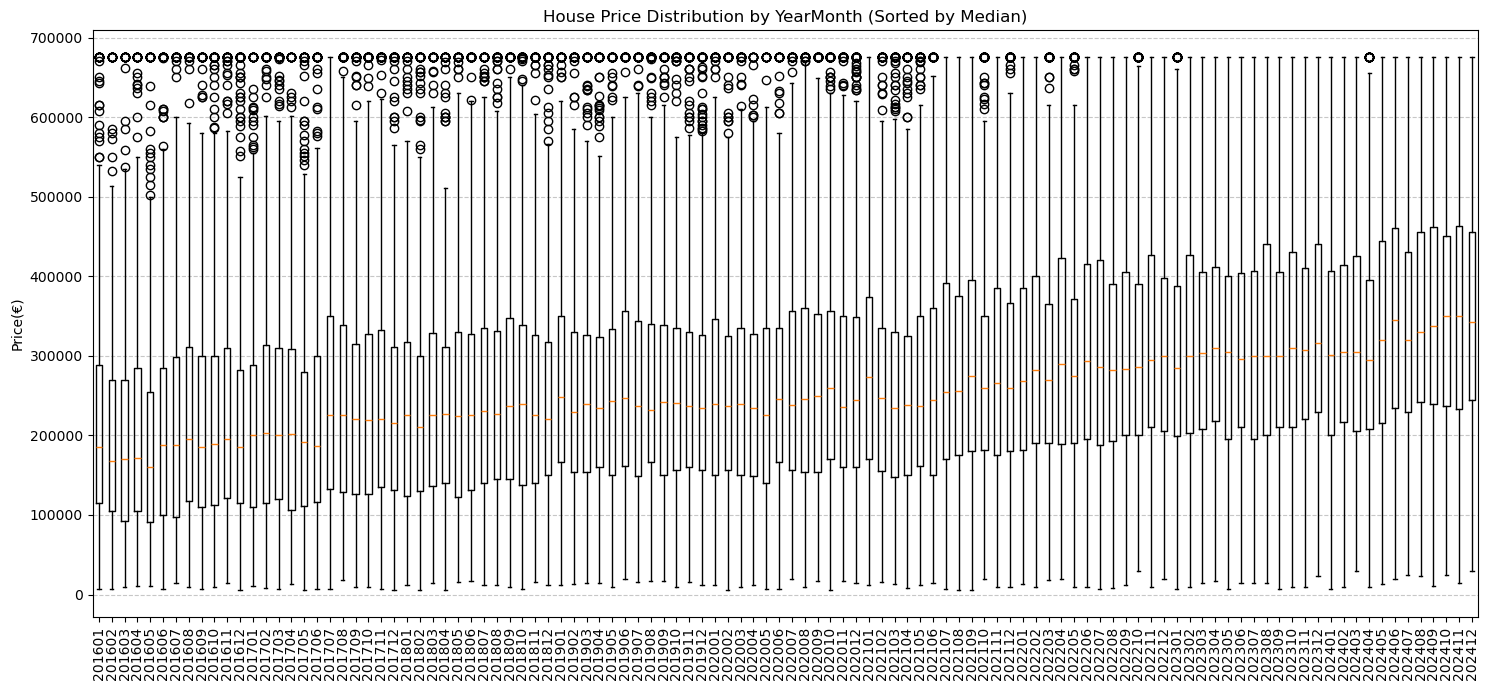

In [12]:
# pair the price with YearMonth

# sort by YearMonth
grouped = df.groupby('YearMonth')['Price(€)'].median()

data_to_plot = [df[df['YearMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by YearMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/1596940852.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/1596940852.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


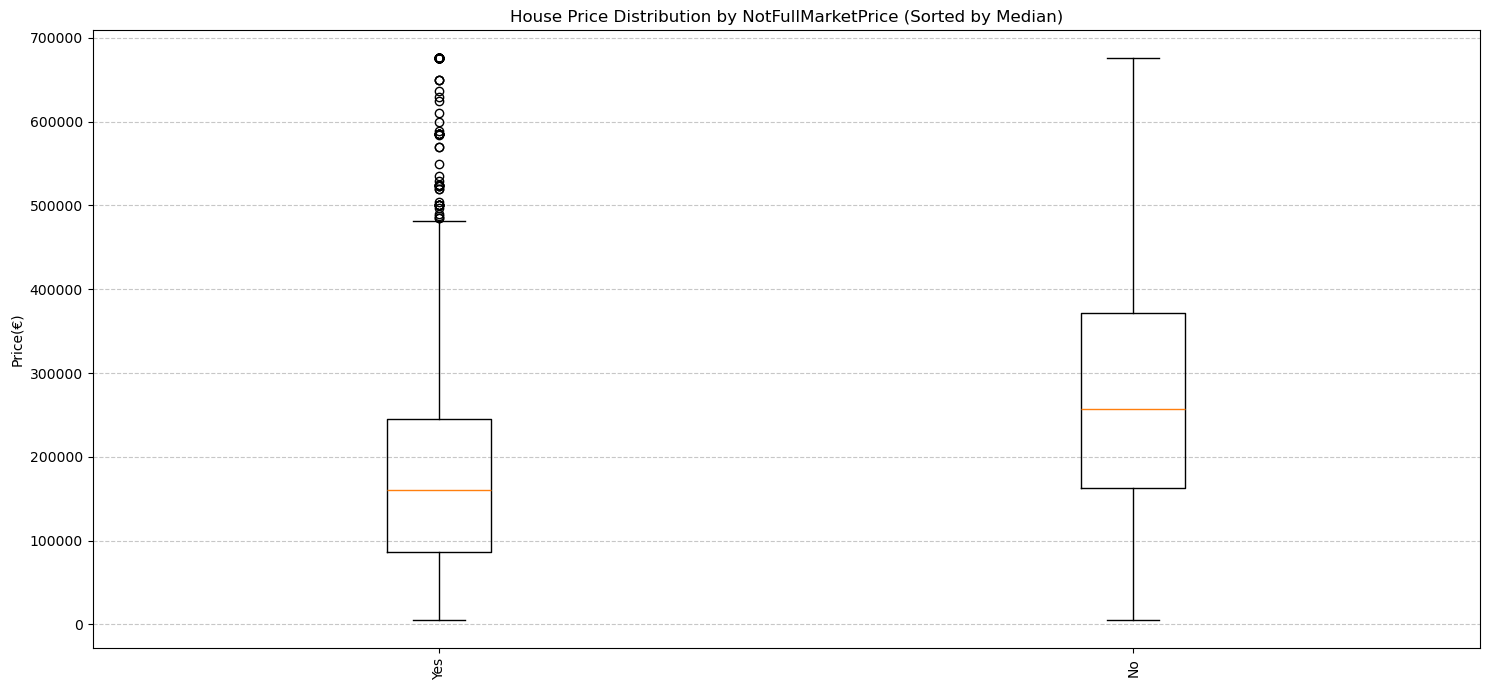

In [13]:
# pair the price with NotFullMarketPrice

# sort by median
grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()

data_to_plot = [df[df['NotFullMarketPrice'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by NotFullMarketPrice (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/3773847616.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/3773847616.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


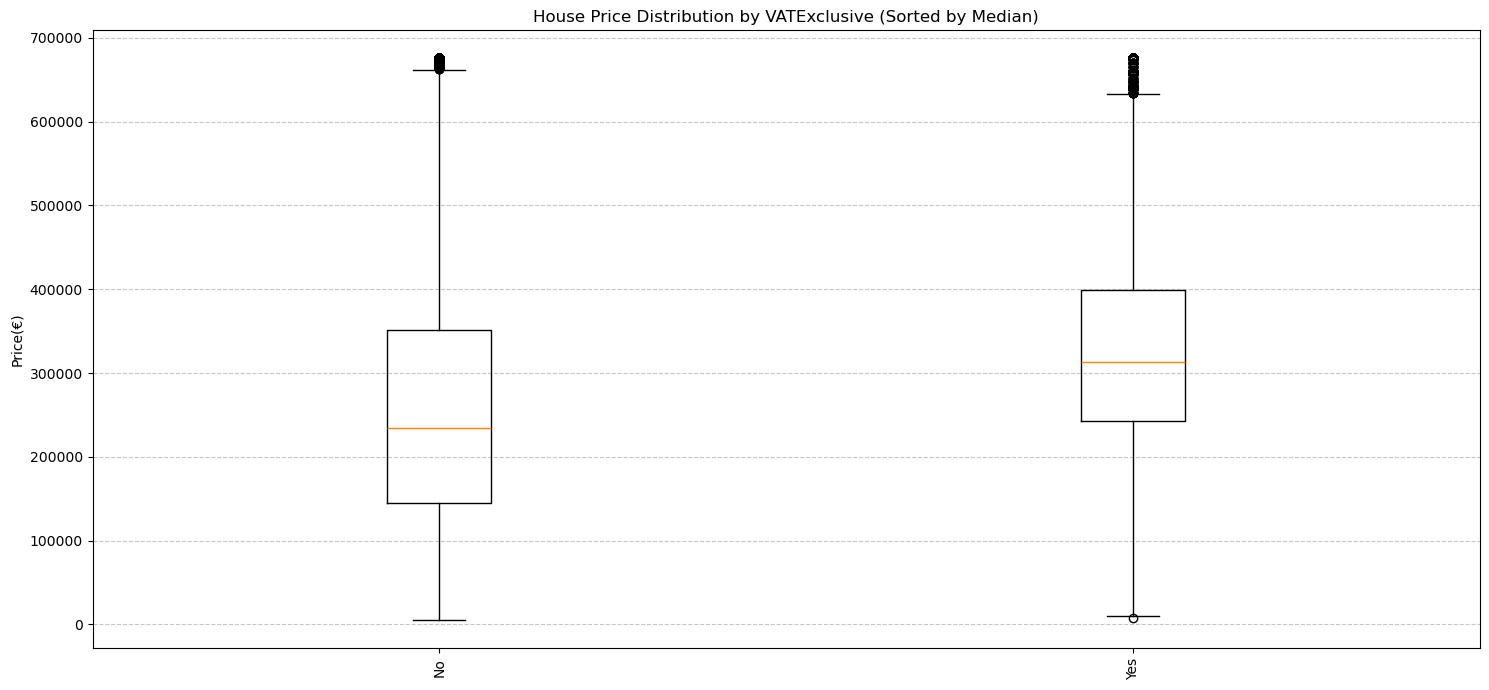

In [14]:
# pair the price with VATExclusive

# sort by median
grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()

data_to_plot = [df[df['VATExclusive'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by VATExclusive (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/2363896353.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()
/var/folders/4q/35st8rg93nz4512q8nsp7lw80000gn/T/ipykernel_30173/2363896353.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


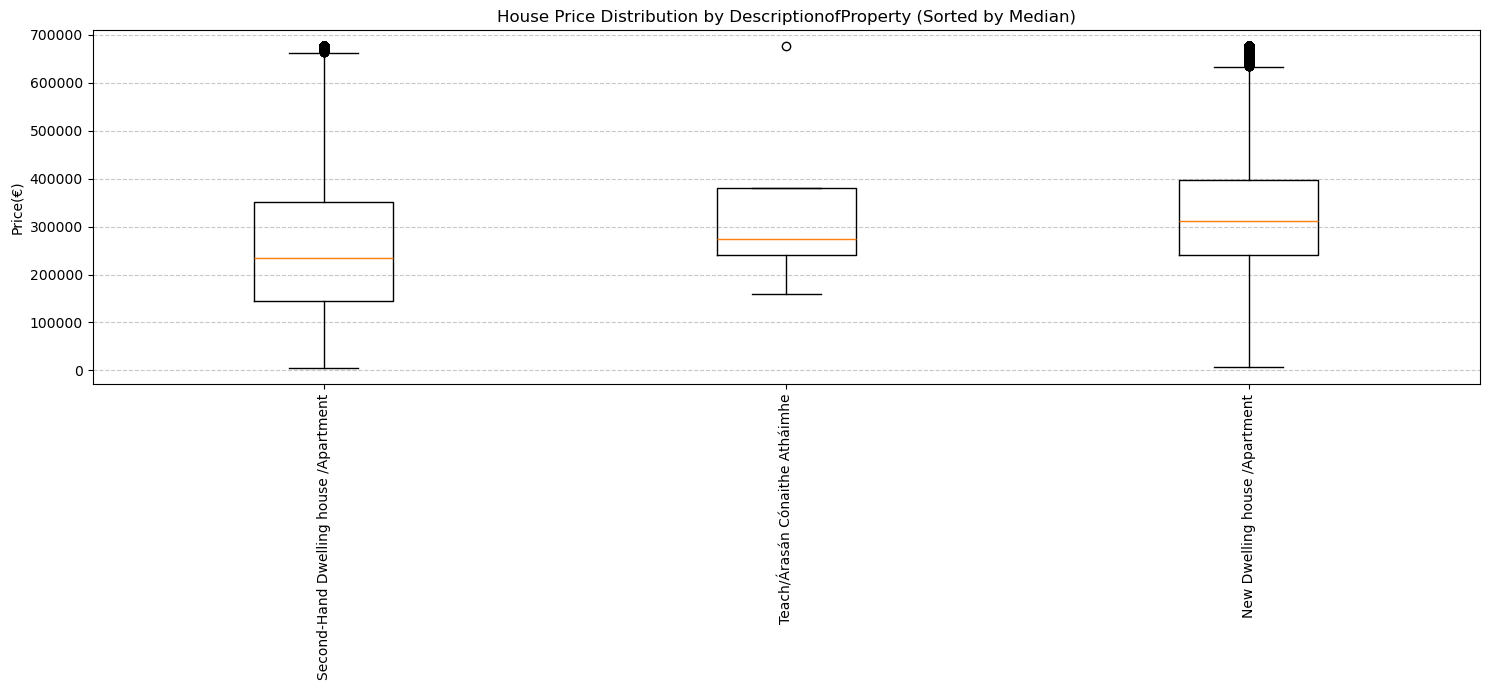

In [15]:
# pair the price with VATExclusive

# sort by median
grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()

data_to_plot = [df[df['DescriptionofProperty'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by DescriptionofProperty (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

In [16]:
df['DescriptionofProperty'].value_counts()

DescriptionofProperty
Second-Hand Dwelling house /Apartment    44139
New Dwelling house /Apartment             9853
Teach/Árasán Cónaithe Atháimhe               4
Name: count, dtype: int64

# Feature Engineering
## 1. SaleYear and SaleMonth
Convert them into a month index

In [17]:
# change data type of saleyear and salemonth
df["SaleYear"] = df["SaleYear"].astype(int)
df["SaleMonth"] = df["SaleMonth"].astype(int)
# create month index starting from 2016-01
df["SaleMonthIndex"] = (df["SaleYear"] - 2016) * 12 + df["SaleMonth"]
# check result
df[["SaleYear", "SaleMonth", "SaleMonthIndex"]].head(12000)

,SaleYear,SaleMonth,SaleMonthIndex
0,2016,7,7
1,2016,12,12
2,2016,8,8
3,2016,2,2
4,2016,10,10
...,...,...,...
11995,2017,4,16
11996,2017,9,21
11997,2017,1,13
11998,2018,10,34


## 2. NotFullMarketPrice
change it into binary number, yes-1, no-0

In [18]:
print(df["NotFullMarketPrice"].unique())
df["NotFullMarketPrice"] = df["NotFullMarketPrice"].map({
    "Yes": 1,
    "No": 0
})
print(df["NotFullMarketPrice"].head())

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
0    0
1    1
2    0
3    0
4    0
Name: NotFullMarketPrice, dtype: category
Categories (2, int64): [0, 1]


## 3. VATExclusive
change it into binary number, yes-1, no-0

In [19]:
print(df["VATExclusive"].unique())
df["VATExclusive"] = df["VATExclusive"].map({
    "Yes": 1,
    "No": 0
})
print(df["VATExclusive"].head())

['No', 'Yes']
Categories (2, object): ['No', 'Yes']
0    0
1    0
2    0
3    1
4    0
Name: VATExclusive, dtype: category
Categories (2, int64): [0, 1]


## 4. DescriptionofProperty
change it into two binary feature, new -1，second-hand -0.    

'Teach/Árasán Cónaithe Atháimhe' means second house/apartment in Irish, so we all merge 'Teach/Árasán Cónaithe Atháimhe' into second-hand house.

In [20]:
print(df["DescriptionofProperty"].unique())

['Second-Hand Dwelling house /Apartment', 'New Dwelling house /Apartment', 'Teach/Árasán Cónaithe Atháimhe']
Categories (3, object): ['New Dwelling house /Apartment', 'Second-Hand Dwelling house /Apartment', 'Teach/Árasán Cónaithe Atháimhe']


In [21]:
df["DescriptionofProperty"] = df["DescriptionofProperty"].map({
    "Second-Hand Dwelling house /Apartment": 0,
    "New Dwelling house /Apartment": 1,
    "Teach/Árasán Cónaithe Atháimhe":0
})
print(df["DescriptionofProperty"].head(1000))

0      0
1      0
2      0
3      1
4      0
      ..
995    0
996    0
997    0
998    1
999    0
Name: DescriptionofProperty, Length: 1000, dtype: int64


In [22]:
df

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region,YearMonth,SaleMonthIndex
0,Wexford,62500.00,0,0,0,2016,7,NON_DUBLIN,201607,7
1,Cork,150000.00,1,0,0,2016,12,NON_DUBLIN,201612,12
2,Wexford,94000.00,0,0,0,2016,8,NON_DUBLIN,201608,8
3,Leitrim,149500.00,0,1,1,2016,2,NON_DUBLIN,201602,2
4,Mayo,170000.00,0,0,0,2016,10,NON_DUBLIN,201610,10
...,...,...,...,...,...,...,...,...,...,...
53991,Kildare,189130.00,0,0,0,2024,12,NON_DUBLIN,202412,108
53992,Clare,110000.00,0,0,0,2024,10,NON_DUBLIN,202410,106
53993,Dublin,440528.63,0,1,1,2024,6,DUBLIN_OTHER,202406,102
53994,Kildare,299559.47,0,1,1,2024,5,NON_DUBLIN,202405,101


## To do list:
### 1. County and Region:
Integrate them into one new feature as GeoEncoding by the method of target encoding, use average price of the county/region as the feature value. To lower the noise, put Dublin19 which has only one row into DUBLIN_OTHER. To avoid data leakage, use 5-fold method to calculate the average price.
### 2. SaleYear and SaleMonth
integrate them together change it into time interval from 2016-00-00, that is (2016-01 is 1, 2016-02 is 2, etc.)
### 3. NotFullMarketPrice
change it into binary number, yes-1, no-0
### 4. VATExclusive
change it into binary number, yes-1, no-0
### 5. DescriptionofProperty
change it into two binary feature isNew and isSecondhand
